# 1. Instalar y montar Drive

In [1]:
!pip install -q ultralytics roboflow
from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 473.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 361.2/361.2 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 10.3 MB/s eta 0:00:00
Mounted at /content/drive


# 2. Descargar el dataset

In [4]:
from google.colab import userdata
from roboflow import Roboflow

rf = Roboflow(api_key=userdata.get("ROBOFLOW_API_KEY"))
project = rf.workspace("thesis-95twb").project("shapes-classification")
version = project.version(1)   # cambien el número por la versión elegida
dataset = version.download("yolov8")   # mismo formato TXT; si aparece "yolov12", úsenlo
print(dataset.location)

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 95.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to Shapes-Classification-1 in yolov8:: 100%|██████████| 7565/7565 [00:00<00:00, 10263.32it/s]


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
/content/Shapes-Classification-1


# 3. Contar imágenes por split y por clase

In [5]:
import glob, collections, yaml, os
root = dataset.location
names = yaml.safe_load(open(f"{root}/data.yaml"))["names"]
for split in ["train", "valid", "test"]:
    imgs = len(glob.glob(f"{root}/{split}/images/*"))
    cnt = collections.Counter()
    for f in glob.glob(f"{root}/{split}/labels/*.txt"):
        for line in open(f):
            if line.strip():
                cnt[names[int(line.split()[0])]] += 1
    print(split, imgs, dict(cnt))

train 3097 {'rectangle': 376, 'triangle': 339, 'oval': 279, 'diamond': 272, 'pyramid': 280, 'cone': 278, 'circle': 407, 'sphere': 336, 'cube': 267, 'cylinder': 364, 'heart': 292, 'square': 397}
valid 455 {'heart': 37, 'pyramid': 39, 'diamond': 37, 'sphere': 48, 'cylinder': 40, 'cube': 45, 'oval': 53, 'rectangle': 61, 'triangle': 44, 'cone': 41, 'circle': 67, 'square': 68}
test 228 {'diamond': 19, 'cylinder': 16, 'oval': 25, 'cube': 23, 'rectangle': 25, 'square': 24, 'pyramid': 25, 'heart': 25, 'cone': 16, 'sphere': 20, 'triangle': 19, 'circle': 20}


# 4. (Recomendado) Quedarse con 3 clases: circle, square, triangle

In [9]:
import shutil, glob, os

keep = ["circle", "square", "triangle"]
id_map = {names.index(c): i for i, c in enumerate(keep)}
out = "/content/shapes3"

# Empezar limpio por si quedó algo de la corrida fallida
shutil.rmtree(out, ignore_errors=True)

for split in ["train", "valid", "test"]:
    os.makedirs(f"{out}/{split}/images", exist_ok=True)
    os.makedirs(f"{out}/{split}/labels", exist_ok=True)
    for lf in glob.glob(f"{root}/{split}/labels/*.txt"):
        rows = []
        for line in open(lf):
            p = line.split()
            if p and int(p[0]) in id_map:
                rows.append(" ".join([str(id_map[int(p[0])])] + p[1:]))
        if rows:
            base = os.path.splitext(os.path.basename(lf))[0]
            matches = glob.glob(f"{root}/{split}/images/{base}.*")
            if matches:
                shutil.copy(matches[0], f"{out}/{split}/images/")
                with open(f"{out}/{split}/labels/{base}.txt", "w") as f:
                    f.write("\n".join(rows))

with open(f"{out}/data.yaml", "w") as f:
    f.write(f"path: {out}\ntrain: train/images\nval: valid/images\ntest: test/images\n"
            f"nc: {len(keep)}\nnames: {keep}\n")

# Verificación rápida
for split in ["train", "valid", "test"]:
    print(split, len(glob.glob(f"{out}/{split}/images/*")), "imágenes")
print(open(f"{out}/data.yaml").read())

train 772 imágenes
valid 129 imágenes
test 56 imágenes
path: /content/shapes3
train: train/images
val: valid/images
test: test/images
nc: 3
names: ['circle', 'square', 'triangle']



# 5. Prueba rápida de entrenamiento

In [10]:
from ultralytics import YOLO
model = YOLO("yolo12n.pt")
model.train(data="/content/shapes3/data.yaml", imgsz=640, epochs=3, batch=16,
            project="/content/drive/MyDrive/yolo_shapes", name="test")

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/shapes3/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=test-2, nbs=64, nms=None, opset=None, optimize=False, optimizer=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x793b8bfa42b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

# 6. Entrenamiento real

In [11]:
from ultralytics import YOLO

model = YOLO("yolo12n.pt")   # si la T4 aguanta y quieren más precisión: yolo12s.pt
results = model.train(
    data="/content/shapes3/data.yaml",
    imgsz=640,
    epochs=50,
    batch=16,          # si sale error de memoria, bajen a 8
    patience=10,       # early stopping
    workers=2,
    project="/content/drive/MyDrive/yolo_shapes",
    name="shapes_n",
    seed=42            # reproducibilidad (útil para el README)
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/shapes3/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=shapes_n, nbs=64, nms=None, opset=None, optimize=False, optimiz

# 7. Validación y métricas por clase

In [12]:
best = YOLO("/content/drive/MyDrive/yolo_shapes/shapes_n/weights/best.pt")
m = best.val(data="/content/shapes3/data.yaml", split="val", imgsz=640)

print(f"mAP@0.5   : {m.box.map50:.3f}")
print(f"mAP@0.5:95: {m.box.map:.3f}")
print(f"Precisión : {m.box.mp:.3f}")
print(f"Recall    : {m.box.mr:.3f}")
for i, name in enumerate(m.names.values()):
    print(f"{name:10s} P={m.box.p[i]:.3f}  R={m.box.r[i]:.3f}  AP50={m.box.ap50[i]:.3f}")

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 7.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 517.6±795.6 MB/s, size: 13.5 KB)
val: Scanning /content/shapes3/valid/labels.cache... 129 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 129/129 45.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 3.1it/s 2.9s
                   all        129        179       0.69      0.712      0.759      0.683
                circle         52         67      0.681      0.701      0.775      0.697
                square         51         68      0.564      0.574      0.612      0.541
              triangle         38         44      0.826       0.86      0.891      0.811
Speed: 3.6ms preprocess, 9.7ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/val
mAP@0.5   : 

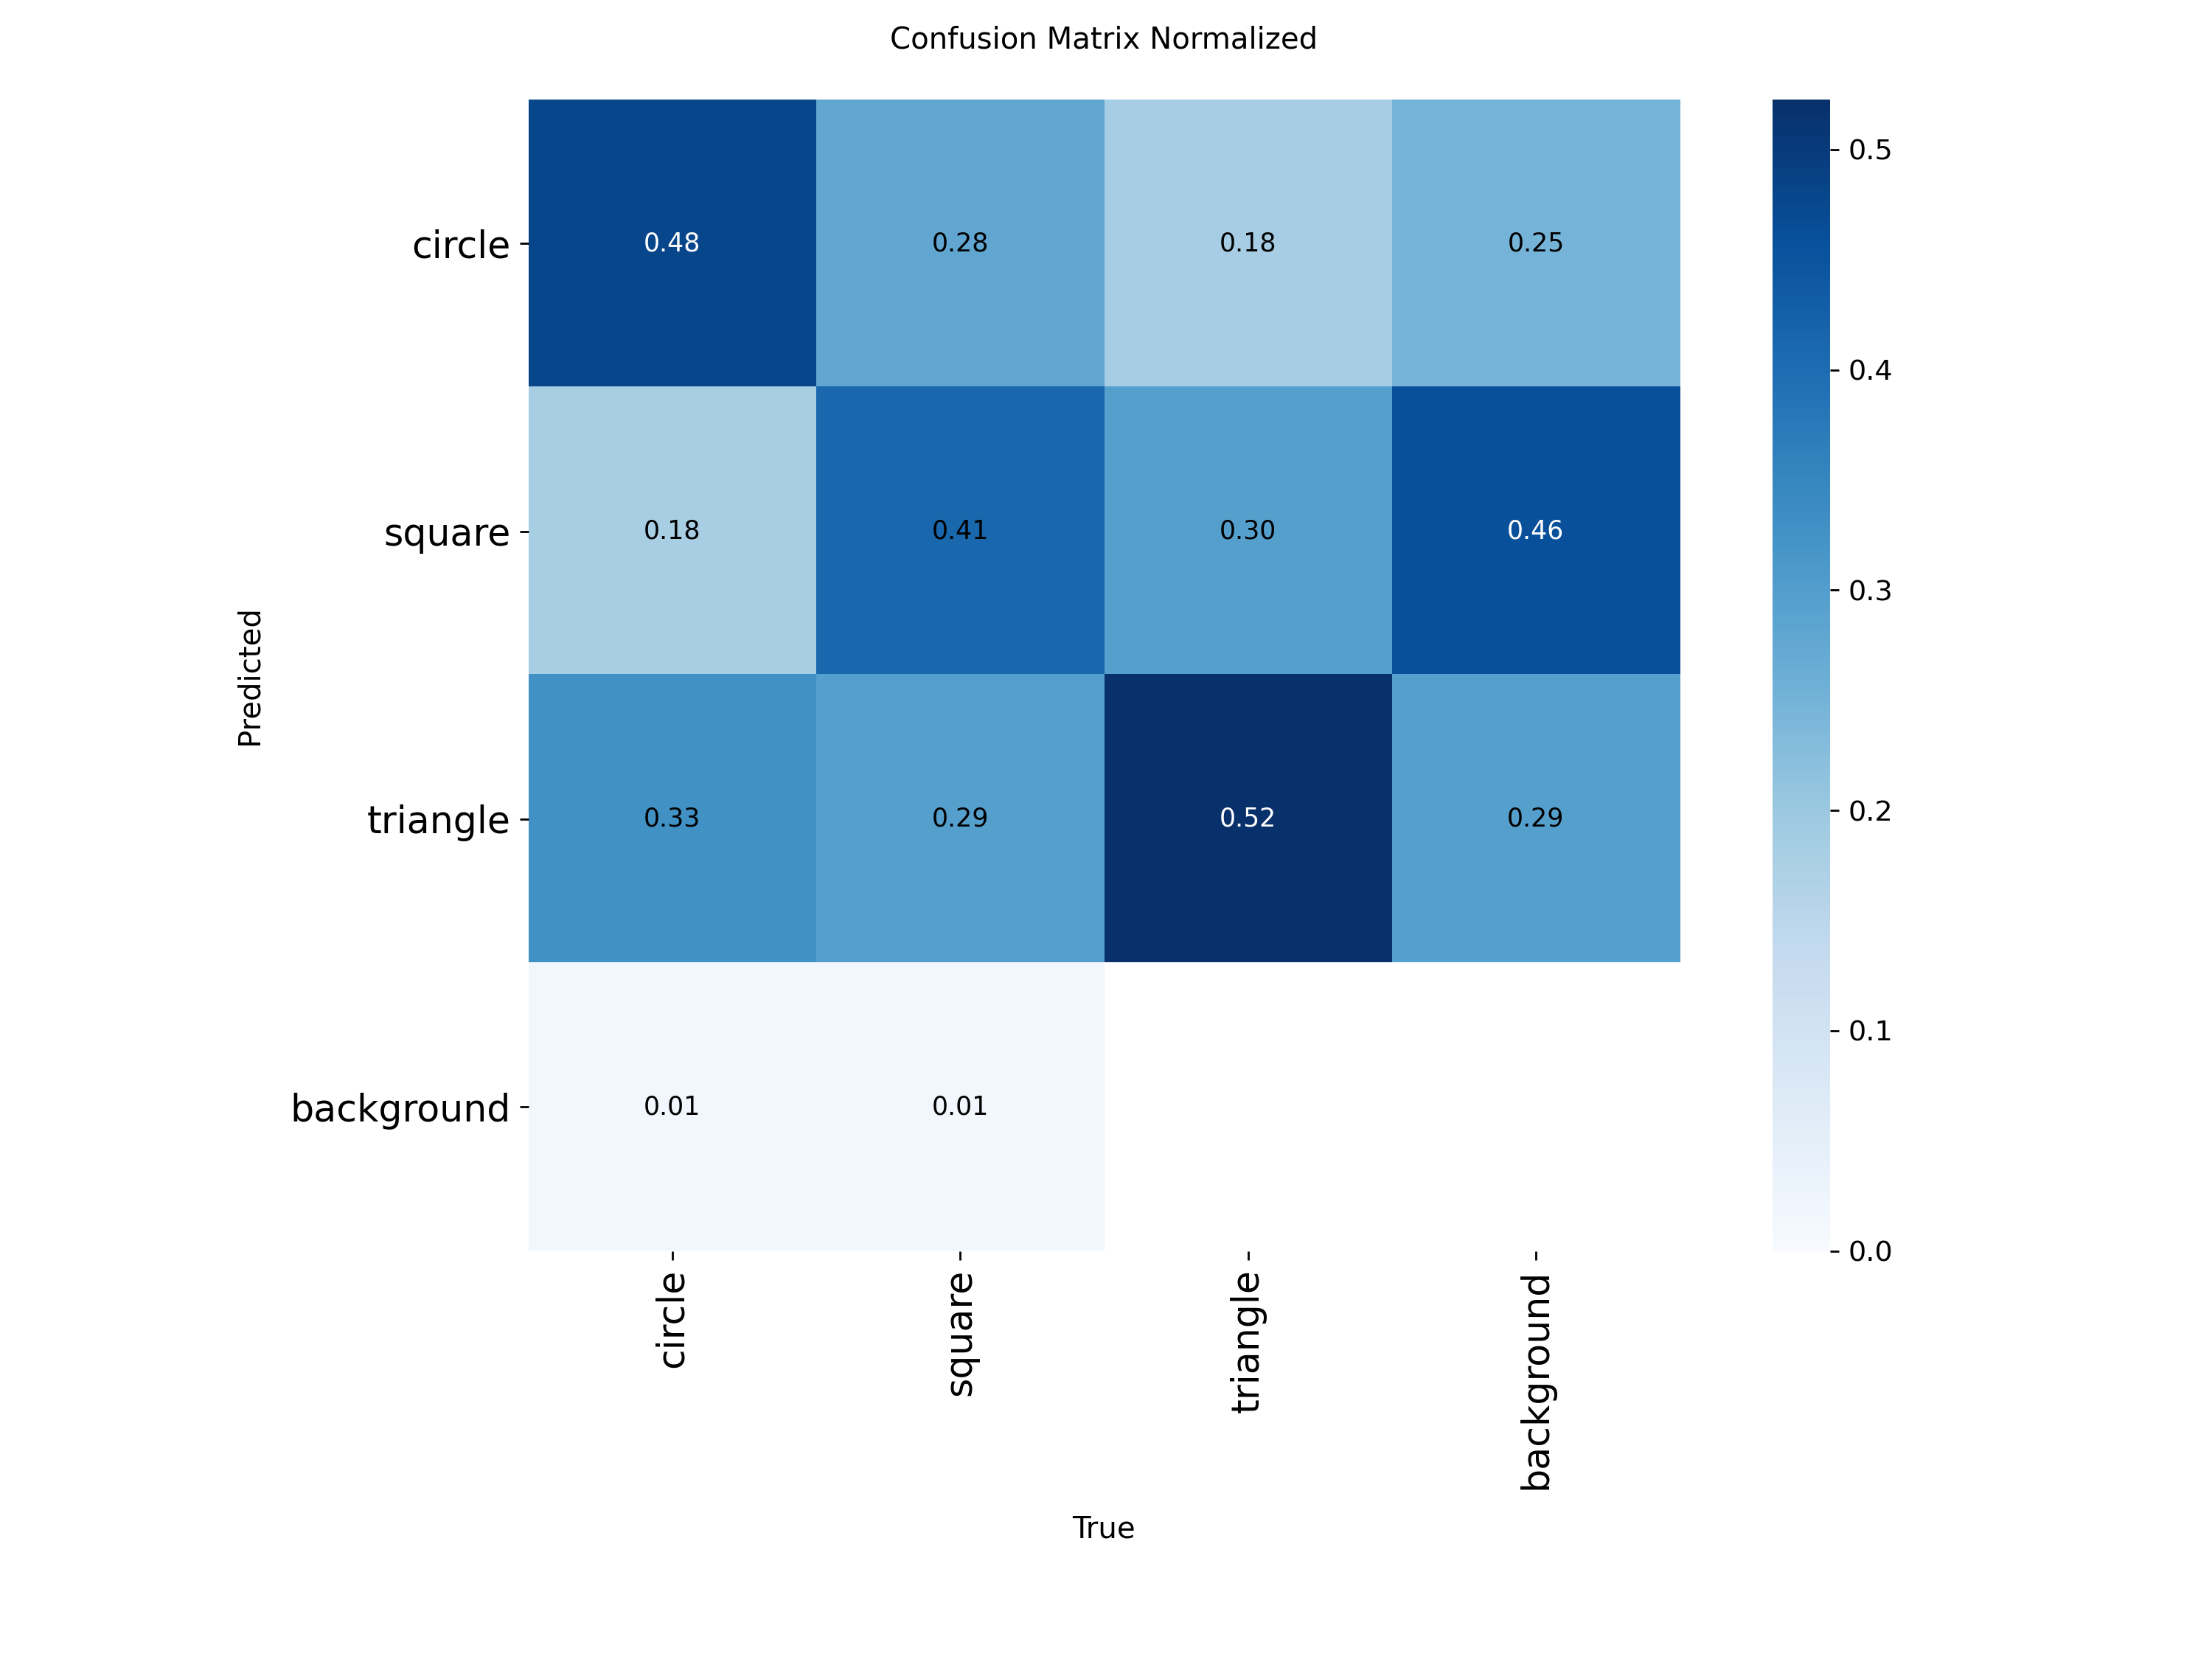

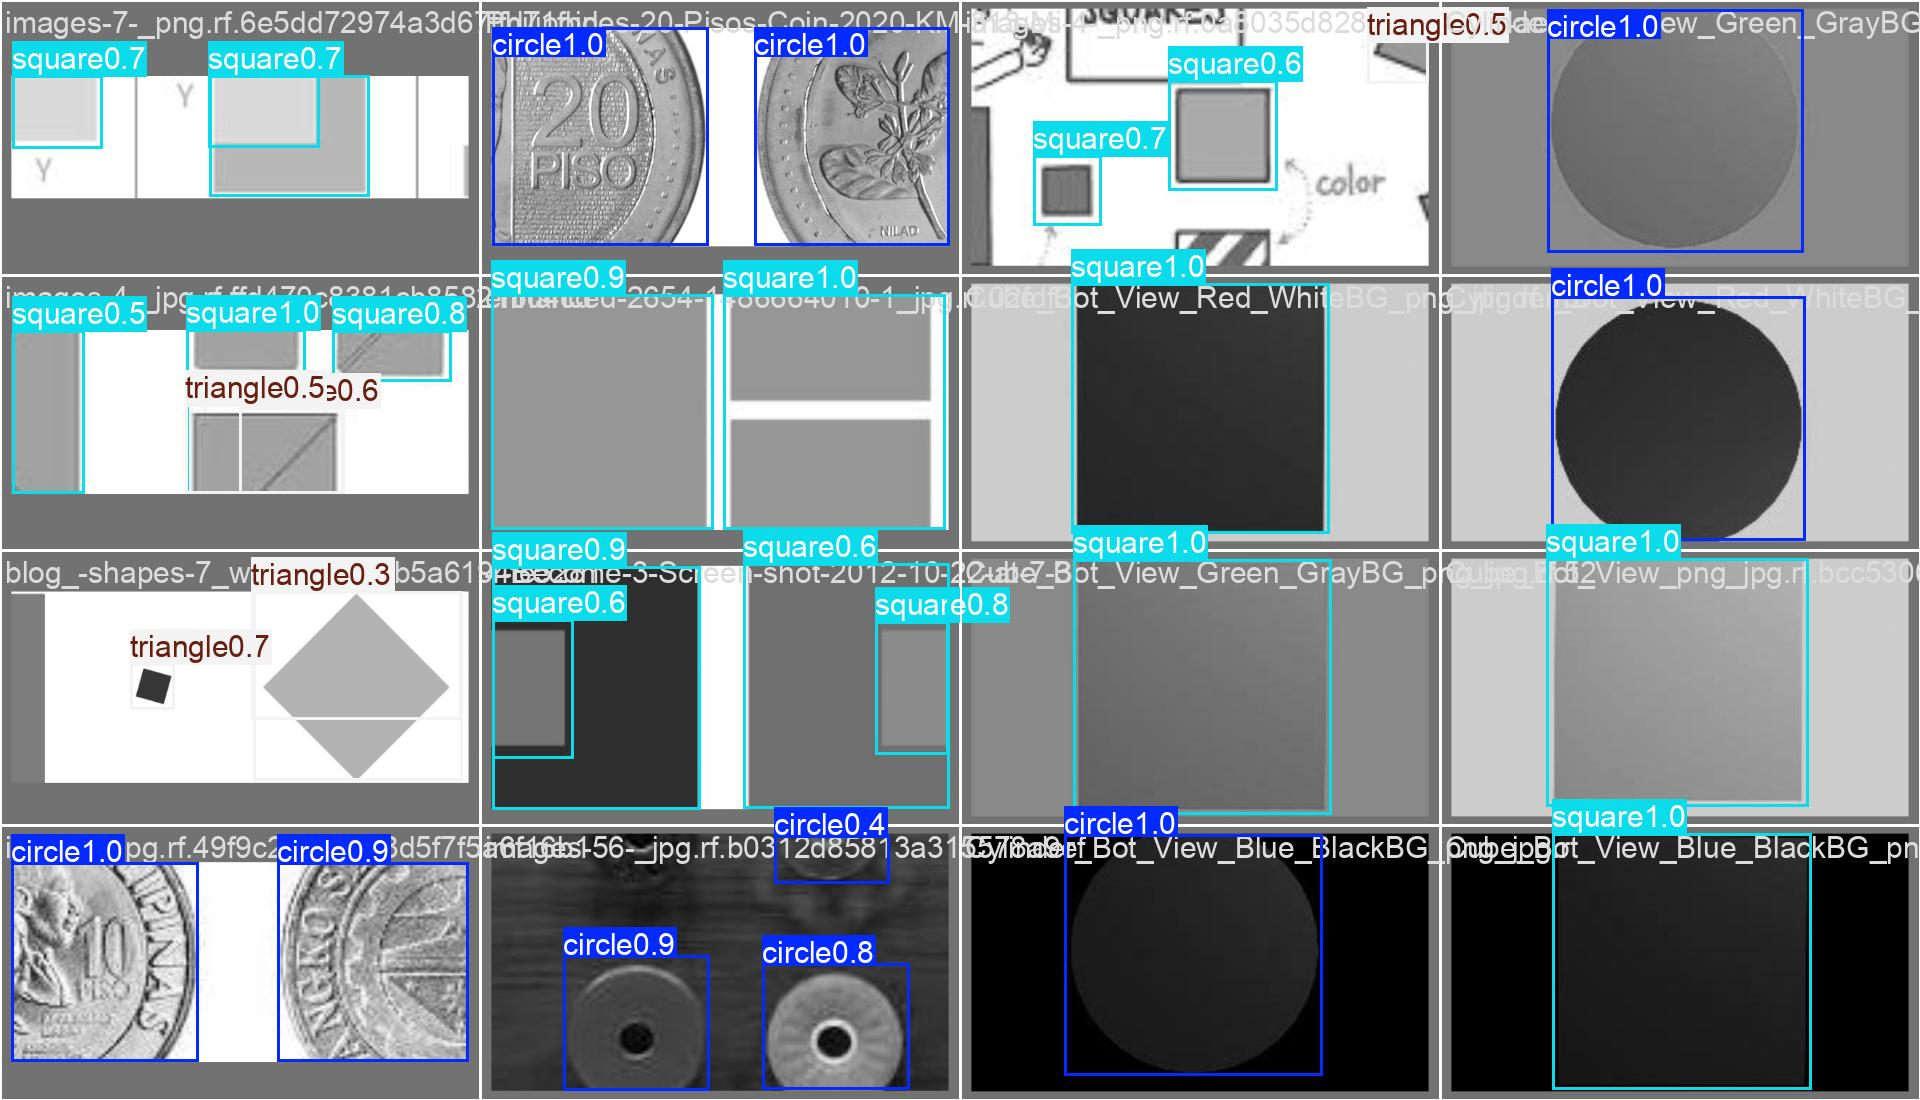

In [13]:
from IPython.display import Image, display
display(Image("/content/runs/detect/val/confusion_matrix_normalized.png"))
display(Image("/content/runs/detect/val/val_batch0_pred.jpg"))

In [14]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/yolo_shapes/shapes_n/results.csv")
df.columns = df.columns.str.strip()
print("épocas:", len(df))
print(df[["epoch", "metrics/mAP50(B)"]].tail())

épocas: 50
    epoch  metrics/mAP50(B)
45     46           0.72546
46     47           0.72683
47     48           0.74659
48     49           0.75406
49     50           0.75554


In [1]:
import glob, os, shutil, random

keep = ["circle", "square", "triangle"]
id_map = {names.index(c): i for i, c in enumerate(keep)}
out = "/content/shapes3b"
shutil.rmtree(out, ignore_errors=True)

# 1) Reunir los 3 splits y quedarse solo con imágenes "limpias"
samples = []
for split in ["train", "valid", "test"]:
    for lf in glob.glob(f"{root}/{split}/labels/*.txt"):
        rows = [l.split() for l in open(lf) if l.strip()]
        if rows and all(int(p[0]) in id_map for p in rows):
            base = os.path.splitext(os.path.basename(lf))[0]
            imgs = glob.glob(f"{root}/{split}/images/{base}.*")
            if imgs:
                new = [" ".join([str(id_map[int(p[0])])] + p[1:]) for p in rows]
                samples.append((imgs[0], base, new))
print("imágenes limpias:", len(samples))

# 2) Re-dividir 70/20/10 con semilla fija
random.seed(42)
random.shuffle(samples)
n = len(samples)
cuts = {"train": samples[:int(.7*n)],
        "valid": samples[int(.7*n):int(.9*n)],
        "test":  samples[int(.9*n):]}

for split, items in cuts.items():
    os.makedirs(f"{out}/{split}/images", exist_ok=True)
    os.makedirs(f"{out}/{split}/labels", exist_ok=True)
    for img, base, rows in items:
        shutil.copy(img, f"{out}/{split}/images/")
        with open(f"{out}/{split}/labels/{base}.txt", "w") as f:
            f.write("\n".join(rows))

with open(f"{out}/data.yaml", "w") as f:
    f.write(f"path: {out}\ntrain: train/images\nval: valid/images\ntest: test/images\n"
            f"nc: {len(keep)}\nnames: {keep}\n")

# 3) Conteos por split y clase
import collections
for split in ["train", "valid", "test"]:
    cnt = collections.Counter()
    for lf in glob.glob(f"{out}/{split}/labels/*.txt"):
        for l in open(lf):
            cnt[keep[int(l.split()[0])]] += 1
    print(split, len(glob.glob(f"{out}/{split}/images/*")), dict(cnt))

NameError: name 'names' is not defined

In [16]:
from ultralytics import YOLO
model = YOLO("yolo12n.pt")
model.train(
    data="/content/shapes3b/data.yaml",
    imgsz=640, epochs=100, batch=16, patience=20, workers=2, seed=42,
    project="/content/drive/MyDrive/yolo_shapes", name="shapes3b_n"
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/shapes3b/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=shapes3b_n, nbs=64, nms=None, opset=None, optimize=False, opt

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x793b98148d00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [18]:
best = YOLO("/content/drive/MyDrive/yolo_shapes/shapes_n/weights/best.pt")
m = best.val(data="/content/shapes3b/data.yaml", split="val", imgsz=640)

print(f"mAP@0.5   : {m.box.map50:.3f}")
print(f"mAP@0.5:95: {m.box.map:.3f}")
print(f"Precisión : {m.box.mp:.3f}")
print(f"Recall    : {m.box.mr:.3f}")
for i, name in enumerate(m.names.values()):
    print(f"{name:10s} P={m.box.p[i]:.3f}  R={m.box.r[i]:.3f}  AP50={m.box.ap50[i]:.3f}")

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 7.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 714.7±988.6 MB/s, size: 17.6 KB)
val: Scanning /content/shapes3b/valid/labels.cache... 170 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 170/170 50.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 3.3it/s 3.4s
                   all        170        231      0.886      0.927      0.955      0.916
                circle         56         69      0.877      0.957      0.972      0.936
                square         60         89      0.856      0.867      0.932      0.885
              triangle         59         73      0.926      0.959      0.962      0.926
Speed: 2.7ms preprocess, 8.5ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val-3
mAP@0.5

In [19]:
import glob, os, json
import numpy as np
from ultralytics import YOLO

WEIGHTS = "/content/drive/MyDrive/yolo_shapes/shapes3b_n/weights/best.pt"
DATA    = "/content/shapes3b"
SPLIT   = "valid"          # para el número que va en el video
CONF, IOU_T = 0.25, 0.5

model = YOLO(WEIGHTS)

def xywhn_to_xyxy(b, w, h):
    xc, yc, bw, bh = b
    return np.array([(xc-bw/2)*w, (yc-bh/2)*h, (xc+bw/2)*w, (yc+bh/2)*h])

def iou(a, b):
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, x2-x1) * max(0, y2-y1)
    union = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter/union if union > 0 else 0

total_gt = tp = fp = 0
imgs = sorted(glob.glob(f"{DATA}/{SPLIT}/images/*"))
for img_path in imgs:
    base = os.path.splitext(os.path.basename(img_path))[0]
    r = model.predict(img_path, conf=CONF, imgsz=640, verbose=False)[0]
    h, w = r.orig_shape
    gts = []
    for line in open(f"{DATA}/{SPLIT}/labels/{base}.txt"):
        p = line.split()
        if p:
            gts.append((int(p[0]), xywhn_to_xyxy(list(map(float, p[1:5])), w, h)))
    preds = sorted(zip(r.boxes.cls.int().tolist(), r.boxes.conf.tolist(),
                       r.boxes.xyxy.cpu().numpy()), key=lambda x: -x[1])
    used = set()
    for cls, conf, box in preds:           # de mayor a menor confianza
        best, best_i = 0, -1
        for i, (gc, gb) in enumerate(gts):
            if i in used or gc != cls:
                continue
            v = iou(box, gb)
            if v > best:
                best, best_i = v, i
        if best >= IOU_T:
            used.add(best_i); tp += 1
        else:
            fp += 1
    total_gt += len(gts)

acc_val    = tp / total_gt                 # métrica del enunciado
acc_strict = tp / (total_gt + fp)          # además penaliza falsos positivos
print(f"GT={total_gt}  TP={tp}  FP={fp}")
print(f"Acc_val = {acc_val:.3f}   |   Acc estricta (con FP) = {acc_strict:.3f}")

os.makedirs("/content/drive/MyDrive/yolo_shapes/metrics", exist_ok=True)
json.dump({"acc_val": round(acc_val, 4), "acc_strict": round(acc_strict, 4),
           "conf": CONF, "iou": IOU_T, "split": SPLIT, "n_images": len(imgs),
           "gt": total_gt, "tp": tp, "fp": fp},
          open("/content/drive/MyDrive/yolo_shapes/metrics/acc_val.json", "w"), indent=2)

GT=231  TP=208  FP=81
Acc_val = 0.900   |   Acc estricta (con FP) = 0.667


In [22]:
   !cd /content && zip -qr /content/drive/MyDrive/yolo_shapes/shapes3b.zip shapes3b

In [23]:
!ls /content/shapes3b/train/images | wc -l
!ls /content/shapes3b/valid/images | wc -l
!ls /content/shapes3b/test/images | wc -l
!md5sum /content/drive/MyDrive/yolo_shapes/shapes3b_n/weights/best.pt

594
170
85
6dc99a3cd4957c6ce974dcbb27fe2d04  /content/drive/MyDrive/yolo_shapes/shapes3b_n/weights/best.pt


In [24]:
from ultralytics import YOLO
w = "/content/drive/MyDrive/yolo_shapes/shapes3b_n/weights/best.pt"
d = "/content/shapes3b/data.yaml"
for dev in (0, "cpu"):
    m = YOLO(w).val(data=d, split="val", imgsz=640, device=dev, plots=False)
    print(">>>", dev, "mAP50:", round(m.box.map50, 3), "P:", round(m.box.mp, 3), "R:", round(m.box.mr, 3))

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 7.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 413.2±390.3 MB/s, size: 12.3 KB)
val: Scanning /content/shapes3b/valid/labels.cache... 170 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 170/170 54.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 6.0it/s 1.8s
                   all        170        231      0.829      0.841      0.916      0.872
                circle         56         69      0.828      0.928      0.954      0.923
                square         60         89      0.841      0.719      0.872      0.818
              triangle         59         73      0.819      0.877      0.924      0.876
Speed: 0.9ms preprocess, 5.4ms inference, 0.0ms loss, 1.2ms postprocess per image
>>> 0 mAP50: 0.916 P: 0.829 R: 0.841
Ultralytics 8.